In [1]:
# We will run the notebook at root level.

import sys
from pathlib import Path

# notebook is one level below root
ROOT = Path.cwd().parent.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [2]:
# Utility functions for accessing and analyzing results

def load_paper_results(paper_id):
    """Load aggregated results for a specific paper."""
    results_file = RESULTS_FOLDER / paper_id / "aggregated" / "results.json"
    if results_file.exists():
        with open(results_file, 'r', encoding='utf-8') as f:
            return json.load(f)
    return None

def load_node_output(paper_id, node_name):
    """Load specific node output for a paper."""
    output_file = RESULTS_FOLDER / paper_id / "raw_outputs" / f"{node_name}.json"
    if output_file.exists():
        with open(output_file, 'r', encoding='utf-8') as f:
            return json.load(f)
    return None

def get_all_papers_gatekeeper_decisions():
    """Get gatekeeper decisions for all papers."""
    decisions = {}
    for paper_dir in RESULTS_FOLDER.glob("*/"):
        if (paper_dir / "aggregated" / "results.json").exists():
            results = load_paper_results(paper_dir.name)
            decisions[paper_dir.name] = results.get("gatekeeper_decision")
    return decisions

print("✅ Utility functions available:")
print("   - load_paper_results(paper_id): Load full results for a paper")
print("   - load_node_output(paper_id, node_name): Load specific node output")
print("   - get_all_papers_gatekeeper_decisions(): Get all gatekeeper decisions")

✅ Utility functions available:
   - load_paper_results(paper_id): Load full results for a paper
   - load_node_output(paper_id, node_name): Load specific node output
   - get_all_papers_gatekeeper_decisions(): Get all gatekeeper decisions


# Evaluation: Agent vs Ground Truth

In [3]:
import csv
import pandas as pd
from pathlib import Path

# Load ground truth benchmark

ROOT = Path(r"c:\Users\sahil\OneDrive\PhD\3. Empirical Study\Methodological Workflow")
PILOT = ROOT / "Pilot_Evaluation"
BENCHMARK_FILE = PILOT / "DATA_sample_10/Data Science Research Process (DSRP) Framework.csv"

# Read CSV, treating first row as header
benchmark_df = pd.read_csv(BENCHMARK_FILE)

# Clean column names
benchmark_df.columns = benchmark_df.columns.str.strip()

print(f"✅ Loaded benchmark with {len(benchmark_df)} annotations")
print(f"\n📊 Benchmark columns ({len(benchmark_df.columns)}):")
for i, col in enumerate(benchmark_df.columns, 1):
    print(f"   {i}. {col}")

# Remove 'Any Comments (Optional)' columns
comment_cols = [col for col in benchmark_df.columns if 'Any Comments' in col or 'Any comments' in col]
benchmark_df_clean = benchmark_df.drop(columns=comment_cols)

print(f"\n🧹 Removed {len(comment_cols)} comment columns")
print(f"📊 Evaluation columns: {len(benchmark_df_clean.columns)}")

# Display sample
print("\n📋 Sample benchmark data:")
print(benchmark_df_clean[["Timestamp", "Paper ID", "Gatekeeper", "research_question"]].head())

✅ Loaded benchmark with 10 annotations

📊 Benchmark columns (45):
   1. Timestamp
   2. Evaluator Name
   3. Paper ID
   4. Gatekeeper
   5. Any Comments (Optional)
   6. research_question
   7. Comment (Optional)
   8. data_category
   9. data_format
   10. data_characteristics
   11. Any comments (Optional)
   12. Data Cleaning
   13. Data Reduction
   14. Data Transformation
   15. Any comments (Optional).1
   16. Foundational Paradigm
   17. Any Comments (Optional).1
   18. ML Learning Type
   19. ML Problem Type
   20. Deep Learning Used
   21. Any comments (optional)
   22. Specialised Paradigms (Skip if none)
   23. Any Comments (Optional).2
   24. evaluation_strategy
   25. learning_type
   26. problem_type
   27. evaluation_metrics_present
   28. validation_procedure
   29. effect_size_reported
   30. assumption_checks_reported
   31. Any comments (Optional).2
   32. explicit_theory
   33. implicit_theory_detected
   34. epistemological_orientation
   35. primary_research_orie

In [4]:
# Define mapping: Agent node output → Benchmark field
# Format: "agent_node": ("benchmark_column", "field_in_node_output", "field_type")
# field_type: "single", "multi_label", "binary"

AGENT_BENCHMARK_MAPPING = {
    "gatekeeper": {
        "benchmark_col": "Gatekeeper",
        "agent_field": "gatekeeper_decision",
        "field_type": "single"
    },
    "research_question": {
        "benchmark_col": "research_question",
        "agent_field": "dsrp_outputs.research_question.final_classification",  # Modify if different
        "field_type": "single"
    },
    "data_understanding": {
        "benchmark_col": "data_category",
        "agent_field": "dsrp_outputs.data_understanding.data_category",
        "field_type": "single"
    },
    "modelling": {
        "benchmark_col": "Foundational Paradigm",
        "agent_field": "dsrp_outputs.modelling.foundational_paradigm",
        "field_type": "single"
    },
    "evaluation_metrics_foundational_node": {
        "benchmark_col": "evaluation_metrics_present",
        "agent_field": "dsrp_outputs.evaluation_metrics.evaluation_metrics_present",
        "field_type": "single"
    },
    "evaluation_theoretical_orientation_node": {
        "benchmark_col": "epistemological_orientation",
        "agent_field": "dsrp_outputs.evaluation_theoretical_orientation.epistemological_orientation",
        "field_type": "single"
    },
    "evaluation_interpretability_node": {
        "benchmark_col": "interpretability_discussed",
        "agent_field": "interpretability_discussed",
        "field_type": "single"
    },
    "evaluation_ethical_social_node": {
        "benchmark_col": "bias_fairness_considered",
        "agent_field": "dsrp_outputs.evaluation_ethical_social.bias_fairness_considered",
        "field_type": "single"
    }
}

print("✅ Agent-Benchmark mapping defined")
print(f"📌 Mapped fields: {len(AGENT_BENCHMARK_MAPPING)}")
for agent_node, mapping in AGENT_BENCHMARK_MAPPING.items():
    print(f"   • {agent_node} → {mapping['benchmark_col']}")

✅ Agent-Benchmark mapping defined
📌 Mapped fields: 8
   • gatekeeper → Gatekeeper
   • research_question → research_question
   • data_understanding → data_category
   • modelling → Foundational Paradigm
   • evaluation_metrics_foundational_node → evaluation_metrics_present
   • evaluation_theoretical_orientation_node → epistemological_orientation
   • evaluation_interpretability_node → interpretability_discussed
   • evaluation_ethical_social_node → bias_fairness_considered


In [5]:
import json 

RESULTS_FOLDER = PILOT /"pilot_study_results"

In [6]:
def normalize_value(value):
    """Normalize values for comparison: handle empty, None, case sensitivity"""
    if pd.isna(value) or value == "" or str(value).strip() == "":
        return None
    return str(value).strip().lower()

def parse_multi_label(value):
    """Parse semicolon-separated values into set"""
    if pd.isna(value) or value == "":
        return set()
    values = str(value).split(";")
    return set(normalize_value(v) for v in values if normalize_value(v))

def extract_agent_values():
    """Extract agent predictions for all papers in results folder"""
    agent_data = {}
    
    for paper_dir in sorted(RESULTS_FOLDER.glob("*/")):
        if not paper_dir.is_dir():
            continue
        
        paper_id = paper_dir.name
        results_file = paper_dir / "aggregated" / "results.json"
        
        if not results_file.exists():
            continue
        
        with open(results_file, 'r', encoding='utf-8') as f:
            results = json.load(f)
        
        agent_data[paper_id] = results
    
    print(f"✅ Extracted agent outputs for {len(agent_data)} papers")
    return agent_data

# Extract agent data
agent_data = extract_agent_values()

# Create comparison dataframe
comparison_data = []

for _, row in benchmark_df_clean.iterrows():
    paper_id = normalize_value(row.get("Paper ID", ""))
    
    if not paper_id or paper_id not in agent_data:
        print(f"⚠️  Paper not found in agent results: {paper_id}")
        continue
    
    agent_results = agent_data[paper_id]
    
    comparison_row = {
        "Paper ID": paper_id,
        "Ground Truth": {},
        "Agent Output": {}
    }
    
    # Extract gatekeeper (binary)
    comparison_row["Ground Truth"]["gatekeeper"] = normalize_value(row.get("Gatekeeper", ""))
    comparison_row["Agent Output"]["gatekeeper"] = normalize_value(
        agent_results.get("gatekeeper_decision", "")
    )
    
    comparison_data.append(comparison_row)

comparison_df = pd.DataFrame(comparison_data)

print(f"\n📊 Created comparison dataset: {len(comparison_df)} papers")
print("\n🔍 Sample comparison:")
print(comparison_df[["Paper ID", "Ground Truth", "Agent Output"]].head())

✅ Extracted agent outputs for 10 papers

📊 Created comparison dataset: 10 papers

🔍 Sample comparison:
    Paper ID               Ground Truth               Agent Output
0   2011 - 1  {'gatekeeper': 'exclude'}  {'gatekeeper': 'exclude'}
1   2018 - 8  {'gatekeeper': 'include'}  {'gatekeeper': 'include'}
2  2018 - 12  {'gatekeeper': 'exclude'}  {'gatekeeper': 'include'}
3  2018 - 26  {'gatekeeper': 'exclude'}  {'gatekeeper': 'include'}
4  2019 - 33  {'gatekeeper': 'include'}  {'gatekeeper': 'include'}


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np

def compute_metrics(y_true, y_pred, field_name, field_type="single"):
    """Compute classification metrics for a single field"""
    
    # Remove None pairs
    valid_pairs = [(t, p) for t, p in zip(y_true, y_pred) if t is not None and p is not None]
    
    if not valid_pairs:
        print(f"⚠️  No valid pairs for {field_name}")
        return None
    
    y_true_clean, y_pred_clean = zip(*valid_pairs)
    
    metrics = {
        "field": field_name,
        "field_type": field_type,
        "valid_samples": len(y_true_clean),
        "accuracy": accuracy_score(y_true_clean, y_pred_clean),
    }
    
    # Get unique classes
    classes = sorted(set(y_true_clean) | set(y_pred_clean))
    
    if len(classes) > 1:
        try:
            metrics["precision"] = precision_score(y_true_clean, y_pred_clean, average='weighted', zero_division=0)
            metrics["recall"] = recall_score(y_true_clean, y_pred_clean, average='weighted', zero_division=0)
            metrics["f1"] = f1_score(y_true_clean, y_pred_clean, average='weighted', zero_division=0)
        except:
            metrics["precision"] = metrics["recall"] = metrics["f1"] = None
    else:
        metrics["precision"] = metrics["recall"] = metrics["f1"] = 1.0
    
    return metrics

# Compute metrics for Gatekeeper
gatekeeper_true = [row["Ground Truth"]["gatekeeper"] for _, row in comparison_df.iterrows()]
gatekeeper_pred = [row["Agent Output"]["gatekeeper"] for _, row in comparison_df.iterrows()]

gatekeeper_metrics = compute_metrics(gatekeeper_true, gatekeeper_pred, "Gatekeeper", "binary")

print("=" * 80)
print("🎯 CLASSIFICATION METRICS: Gatekeeper (Binary)")
print("=" * 80)
if gatekeeper_metrics:
    for key, value in gatekeeper_metrics.items():
        if isinstance(value, float):
            print(f"{key:.<25} {value:.4f}")
        else:
            print(f"{key:.<25} {value}")

# Confusion matrix
if gatekeeper_metrics:
    from sklearn.metrics import ConfusionMatrixDisplay
    import matplotlib.pyplot as plt
    
    y_true_clean = [t for t, p in zip(gatekeeper_true, gatekeeper_pred) if t and p]
    y_pred_clean = [p for t, p in zip(gatekeeper_true, gatekeeper_pred) if t and p]
    
    cm = confusion_matrix(y_true_clean, y_pred_clean, labels=sorted(set(y_true_clean)))
    print(f"\n🔢 Confusion Matrix:")
    print(cm)

🎯 CLASSIFICATION METRICS: Gatekeeper (Binary)
field.................... Gatekeeper
field_type............... binary
valid_samples............ 10
accuracy................. 0.8000
precision................ 0.8444
recall................... 0.8000
f1....................... 0.7625

🔢 Confusion Matrix:
[[1 2]
 [0 7]]


In [8]:
# Comparison details
print("\n\n📋 DETAILED COMPARISON: Gatekeeper Decisions\n")
comparison_display = comparison_df.copy()
comparison_display["GT"] = comparison_display["Ground Truth"].apply(lambda x: x["gatekeeper"])
comparison_display["Agent"] = comparison_display["Agent Output"].apply(lambda x: x["gatekeeper"])
comparison_display["Match"] = comparison_display.apply(
    lambda row: "✅" if row["GT"] == row["Agent"] else "❌", axis=1
)

print(comparison_display[["Paper ID", "GT", "Agent", "Match"]].to_string(index=False))

# Summary statistics
matches = (comparison_display["GT"] == comparison_display["Agent"]).sum()
total = len(comparison_display)
print(f"\n\n📊 Overall Agreement: {matches}/{total} ({100*matches/total:.1f}%)")

# Per-class breakdown
print("\n📈 Per-Class Breakdown:")
for decision in sorted(set(comparison_display["GT"])):
    gt_count = (comparison_display["GT"] == decision).sum()
    correct = ((comparison_display["GT"] == decision) & (comparison_display["Agent"] == decision)).sum()
    accuracy = correct / gt_count if gt_count > 0 else 0
    print(f"   {decision:.<20} GT: {gt_count:2d} papers, Correct: {correct:2d}, Accuracy: {100*accuracy:.1f}%")



📋 DETAILED COMPARISON: Gatekeeper Decisions

 Paper ID      GT   Agent Match
 2011 - 1 exclude exclude     ✅
 2018 - 8 include include     ✅
2018 - 12 exclude include     ❌
2018 - 26 exclude include     ❌
2019 - 33 include include     ✅
 2020 - 8 include include     ✅
2021 - 28 include include     ✅
2021 - 56 include include     ✅
2023 - 58 include include     ✅
2024 - 99 include include     ✅


📊 Overall Agreement: 8/10 (80.0%)

📈 Per-Class Breakdown:
   exclude............. GT:  3 papers, Correct:  1, Accuracy: 33.3%
   include............. GT:  7 papers, Correct:  7, Accuracy: 100.0%


In [9]:
from datetime import datetime

# Save evaluation results
EVALUATION_FOLDER = PILOT / "pilot_study_evaluation"
EVALUATION_FOLDER.mkdir(exist_ok=True)

# Save comparison data
comparison_display.to_csv(EVALUATION_FOLDER / "gatekeeper_comparison.csv", index=False)

# Save metrics summary
metrics_summary = {
    "field": "Gatekeeper",
    "field_type": "Binary Classification",
    "timestamp": datetime.now().isoformat(),
    "metrics": gatekeeper_metrics,
    "overall_accuracy": gatekeeper_metrics["accuracy"] if gatekeeper_metrics else None,
    "total_papers": len(comparison_display),
    "matches": matches,
    "per_class_breakdown": {}
}

# Per-class breakdown
for decision in sorted(set(comparison_display["GT"])):
    gt_count = (comparison_display["GT"] == decision).sum()
    correct = ((comparison_display["GT"] == decision) & (comparison_display["Agent"] == decision)).sum()
    accuracy = correct / gt_count if gt_count > 0 else 0
    metrics_summary["per_class_breakdown"][decision] = {
        "ground_truth_count": int(gt_count),
        "correct_predictions": int(correct),
        "accuracy": float(accuracy)
    }

def to_native(o):
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    raise TypeError(f"Object of type {type(o).__name__} is not JSON serializable")

with open(EVALUATION_FOLDER / "gatekeeper_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False, default=to_native)

    
print(f"\n✅ Evaluation results saved:")
print(f"   📁 {EVALUATION_FOLDER.resolve().relative_to(Path.cwd().resolve())}/")
print(f"   📊 gatekeeper_comparison.csv - Detailed predictions")
print(f"   📈 gatekeeper_metrics.json - Summary metrics")


✅ Evaluation results saved:
   📁 pilot_study_evaluation/
   📊 gatekeeper_comparison.csv - Detailed predictions
   📈 gatekeeper_metrics.json - Summary metrics


## Multi-Field Evaluation

In [10]:
# Enhanced mapping aligned to actual aggregated result schema
ENHANCED_BENCHMARK_MAPPING = {
    "Gatekeeper": {
        "agent_source": "gatekeeper_decision",
        "field_type": "single",
        "description": "Paper inclusion decision"
    },
    "Deep Learning Used": {
        "agent_source": "dsrp_outputs.modelling.deep_learning_used",
        "field_type": "binary",
        "description": "Whether deep learning was applied"
    },
    "Privacy_protection_reported": {
        "agent_source": "dsrp_outputs.evaluation_ethical_social.privacy_protection_reported",
        "field_type": "binary",
        "description": "Privacy protection measures"
    },
    "bias_fairness_considered": {
        "agent_source": "dsrp_outputs.evaluation_ethical_social.bias_fairness_considered",
        "field_type": "binary",
        "description": "Bias and fairness considerations"
    },
    "research_question": {
        "agent_source": "dsrp_outputs.research_question.final_classification",
        "field_type": "single",
        "description": "Type of research question"
    },
    "data_category": {
        "agent_source": "dsrp_outputs.data_understanding.data_category",
        "field_type": "multi_label",
        "description": "Data category/source"
    },
    "data_format": {
        "agent_source": "dsrp_outputs.data_understanding.data_format",
        "field_type": "multi_label",
        "description": "Data format (structured/unstructured)"
    },
    "Foundational Paradigm": {
        "agent_source": "dsrp_outputs.modelling.foundational_paradigm",
        "field_type": "single",
        "description": "ML/Statistical paradigm"
    },
    "epistemological_orientation": {
        "agent_source": "dsrp_outputs.evaluation_theoretical_orientation.epistemological_orientation",
        "field_type": "single",
        "description": "Epistemological stance"
    },
    "interpretability_discussed": {
        "agent_source": "dsrp_outputs.evaluation_interpretability.interpretability_discussed",
        "field_type": "binary",
        "description": "Model interpretability discussion"
    },
    "evaluation_metrics_present": {
        "agent_source": "dsrp_outputs.evaluation_metrics.evaluation_metrics_present",
        "field_type": "binary",
        "description": "Evaluation metrics reported"
    },
    "data_characteristics": {
        "agent_source": "dsrp_outputs.data_understanding.data_characteristics",
        "field_type": "multi_label",
        "description": "Data characteristics (temporal, spatial, textual, etc.)"
    },
    "ML Problem Type": {
        "agent_source": "dsrp_outputs.modelling.ml_problem_type",
        "field_type": "multi_label",
        "description": "ML problem types"
    }
}

print("✅ Enhanced benchmark mapping created")
print(f"📊 Total fields to evaluate: {len(ENHANCED_BENCHMARK_MAPPING)}")
print("\nField breakdown:")
single_count = sum(1 for m in ENHANCED_BENCHMARK_MAPPING.values() if m["field_type"] == "single")
binary_count = sum(1 for m in ENHANCED_BENCHMARK_MAPPING.values() if m["field_type"] == "binary")
multi_count = sum(1 for m in ENHANCED_BENCHMARK_MAPPING.values() if m["field_type"] == "multi_label")
print(f"  - Single-class: {single_count}")
print(f"  - Binary: {binary_count}")
print(f"  - Multi-label: {multi_count}")

✅ Enhanced benchmark mapping created
📊 Total fields to evaluate: 13

Field breakdown:
  - Single-class: 4
  - Binary: 5
  - Multi-label: 4


In [24]:
def normalize_value(value):
    """Normalize scalar values for robust matching across benchmark and agent outputs."""
    if value is None:
        return None
    if isinstance(value, float) and pd.isna(value):
        return None
    if isinstance(value, bool):
        return "yes" if value else "no"

    text = str(value).strip().lower()
    if text == "":
        return None

    # Canonical spacing and separators
    text = " ".join(text.split())
    text = text.replace(" / ", "/").replace("; ", ";")

    # Canonical labels for common variants
    alias_map = {
        "survey / statistical": "survey/statistical",
        "survey/statistical": "survey/statistical",
        "not reported": "not reported",
        "not applicable": "not applicable",
        "true": "yes",
        "false": "no"
    }
    return alias_map.get(text, text)


def parse_multi_label(value):
    """Convert semicolon-separated strings or lists into normalized sets."""
    if value is None:
        return set()
    if isinstance(value, float) and pd.isna(value):
        return set()

    if isinstance(value, list):
        return {normalize_value(v) for v in value if normalize_value(v) is not None}

    text = str(value).strip()
    if text == "":
        return set()

    parts = [p.strip() for p in text.split(";")]
    return {normalize_value(p) for p in parts if normalize_value(p) is not None}


def extract_nested_value(obj, path):
    """Extract value from nested dict using dot notation path."""
    keys = path.split(".")
    result = obj
    for key in keys:
        if isinstance(result, dict):
            result = result.get(key)
        else:
            return None
    return result


def compute_multi_label_metrics(y_true_sets, y_pred_sets, field_name):
    """Compute metrics for multi-label classification."""
    from sklearn.metrics import hamming_loss

    # Keep pairs where both are available sets (possibly empty)
    valid_pairs = [
        (t, p) for t, p in zip(y_true_sets, y_pred_sets)
        if t is not None and p is not None
    ]

    if not valid_pairs:
        print(f"WARNING: No valid pairs for {field_name}")
        return None

    y_true_clean, y_pred_clean = zip(*valid_pairs)

    all_labels = set()
    for t, p in zip(y_true_clean, y_pred_clean):
        all_labels.update(t)
        all_labels.update(p)

    if not all_labels:
        return {
            "field": field_name,
            "field_type": "multi_label",
            "valid_samples": len(y_true_clean),
            "hamming_loss": 0.0,
            "exact_match_ratio": 1.0,
            "per_label_accuracy": {}
        }

    all_labels = sorted(all_labels)
    y_true_binary = [[1 if label in t else 0 for label in all_labels] for t in y_true_clean]
    y_pred_binary = [[1 if label in p else 0 for label in all_labels] for p in y_pred_clean]

    metrics = {
        "field": field_name,
        "field_type": "multi_label",
        "valid_samples": len(y_true_clean),
        "hamming_loss": hamming_loss(y_true_binary, y_pred_binary)
    }

    exact = sum(1 for t, p in zip(y_true_clean, y_pred_clean) if t == p)
    metrics["exact_match_ratio"] = exact / len(y_true_clean)

    per_label_accuracy = {}
    for i, label in enumerate(all_labels):
        correct = sum(
            1 for j in range(len(y_true_binary))
            if y_true_binary[j][i] == y_pred_binary[j][i]
        )
        per_label_accuracy[label] = correct / len(y_true_binary)

    metrics["per_label_accuracy"] = per_label_accuracy
    return metrics


def build_comprehensive_comparison():
    """Build comparison dataframe for all mapped fields."""
    all_comparisons = []

    for _, gt_row in benchmark_df_clean.iterrows():
        paper_id_raw = gt_row.get("Paper ID", "")
        paper_id = normalize_value(paper_id_raw)

        if not paper_id:
            continue

        # Agent folders are keyed by original paper id casing; numeric ids are case-safe.
        matched_key = None
        for k in agent_data.keys():
            if normalize_value(k) == paper_id:
                matched_key = k
                break

        if matched_key is None:
            continue

        agent_result = agent_data[matched_key]
        comp_row = {"Paper ID": matched_key}

        for field_name, mapping in ENHANCED_BENCHMARK_MAPPING.items():
            gt_value = gt_row.get(field_name)
            field_type = mapping["field_type"]

            agent_value = extract_nested_value(agent_result, mapping["agent_source"])

            if field_type == "multi_label":
                gt_normalized = parse_multi_label(gt_value)
                agent_normalized = parse_multi_label(agent_value)
            else:
                gt_normalized = normalize_value(gt_value)
                agent_normalized = normalize_value(agent_value)

            comp_row[f"{field_name}_GT"] = gt_normalized
            comp_row[f"{field_name}_Agent"] = agent_normalized
            comp_row[f"{field_name}_Match"] = (gt_normalized == agent_normalized)

        all_comparisons.append(comp_row)

    return pd.DataFrame(all_comparisons)


# Build comprehensive comparison
multi_field_comparison = build_comprehensive_comparison()

print(f"✅ Built comprehensive comparison for {len(multi_field_comparison)} papers")
print(f"📊 Evaluating {len(ENHANCED_BENCHMARK_MAPPING)} fields")

✅ Built comprehensive comparison for 10 papers
📊 Evaluating 13 fields


In [25]:
# Compute metrics for all fields
all_metrics = {}

print("=" * 100)
print("MULTI-FIELD CLASSIFICATION METRICS")
print("=" * 100 + "\n")

for field_name, mapping in ENHANCED_BENCHMARK_MAPPING.items():
    field_type = mapping["field_type"]

    gt_col = f"{field_name}_GT"
    agent_col = f"{field_name}_Agent"

    if gt_col not in multi_field_comparison.columns:
        print(f"WARNING: {field_name}: Column not found")
        continue

    gt_values = multi_field_comparison[gt_col].tolist()
    agent_values = multi_field_comparison[agent_col].tolist()

    # Compute metrics based on field type
    if field_type == "multi_label":
        metrics = compute_multi_label_metrics(gt_values, agent_values, field_name)
    else:
        metrics = compute_metrics(gt_values, agent_values, field_name, field_type)

    if metrics:
        all_metrics[field_name] = metrics

        # Print summary
        print(f"- {field_name}")
        print(f"  Type: {field_type} | Description: {mapping['description']}")
        if field_type == "multi_label":
            print(f"  Hamming Loss: {metrics['hamming_loss']:.4f}")
            print(f"  Exact Match Ratio: {metrics['exact_match_ratio']:.4f}")
            print(f"  Valid Samples: {metrics['valid_samples']}")
        else:
            f1_value = metrics.get("f1")
            f1_text = f"{f1_value:.4f}" if f1_value is not None else "N/A"
            print(f"  Accuracy: {metrics['accuracy']:.4f} | F1: {f1_text}")
            print(f"  Valid Samples: {metrics['valid_samples']}")
        print()

print("=" * 100)

MULTI-FIELD CLASSIFICATION METRICS

- Gatekeeper
  Type: single | Description: Paper inclusion decision
  Accuracy: 0.8000 | F1: 0.7625
  Valid Samples: 10

- Deep Learning Used
  Type: binary | Description: Whether deep learning was applied
  Accuracy: 1.0000 | F1: 1.0000
  Valid Samples: 6

- Privacy_protection_reported
  Type: binary | Description: Privacy protection measures
  Accuracy: 1.0000 | F1: 1.0000
  Valid Samples: 7

- bias_fairness_considered
  Type: binary | Description: Bias and fairness considerations
  Accuracy: 1.0000 | F1: 1.0000
  Valid Samples: 7

- research_question
  Type: single | Description: Type of research question
  Accuracy: 0.5714 | F1: 0.6905
  Valid Samples: 7

- data_category
  Type: multi_label | Description: Data category/source
  Hamming Loss: 0.2500
  Exact Match Ratio: 0.5000
  Valid Samples: 10

- data_format
  Type: multi_label | Description: Data format (structured/unstructured)
  Hamming Loss: 0.3333
  Exact Match Ratio: 0.4000
  Valid Sample

In [26]:
# Create summary metrics table
print("\n📊 METRICS SUMMARY TABLE\n")

summary_records = []
for field_name, metrics in all_metrics.items():
    record = {
        "Field": field_name,
        "Type": metrics["field_type"],
        "Samples": metrics["valid_samples"]
    }
    
    if metrics["field_type"] == "multi_label":
        record["Exact Match"] = f"{metrics['exact_match_ratio']:.4f}"
        record["Hamming Loss"] = f"{metrics['hamming_loss']:.4f}"
        record["F1"] = "-"
    else:
        record["Accuracy"] = f"{metrics['accuracy']:.4f}"
        record["Precision"] = f"{metrics['precision']:.4f}" if metrics['precision'] else "N/A"
        record["Recall"] = f"{metrics['recall']:.4f}" if metrics['recall'] else "N/A"
        record["F1"] = f"{metrics['f1']:.4f}" if metrics['f1'] else "N/A"
    
    summary_records.append(record)

summary_table = pd.DataFrame(summary_records)
print(summary_table.to_string(index=False))

# Compute overall metrics
overall_accuracy = summary_table[(summary_table["Type"] != "multi_label")]["Accuracy"].str.extract(r'(\d+\.\d+)', expand=False).astype(float).mean()
overall_f1 = summary_table[(summary_table["F1"] != "-") & (summary_table["Type"] != "multi_label")]["F1"].str.extract(r'(\d+\.\d+)', expand=False).astype(float).mean()
overall_exact_match = summary_table[(summary_table["Type"] == "multi_label")]["Exact Match"].str.extract(r'(\d+\.\d+)', expand=False).astype(float).mean()

print(f"\n{'='*80}")
print(f"📈 OVERALL PERFORMANCE")
print(f"{'='*80}")
print(f"Average Accuracy (single-class fields): {overall_accuracy:.4f}")
if not pd.isna(overall_f1):
    print(f"Average F1 Score: {overall_f1:.4f}")
if not pd.isna(overall_exact_match):
    print(f"Average Exact Match Ratio (multi-label): {overall_exact_match:.4f}")
print(f"Total Fields Evaluated: {len(all_metrics)}")


📊 METRICS SUMMARY TABLE

                      Field        Type  Samples Accuracy Precision Recall     F1 Exact Match Hamming Loss
                 Gatekeeper      single       10   0.8000    0.8444 0.8000 0.7625         NaN          NaN
         Deep Learning Used      binary        6   1.0000    1.0000 1.0000 1.0000         NaN          NaN
Privacy_protection_reported      binary        7   1.0000    1.0000 1.0000 1.0000         NaN          NaN
   bias_fairness_considered      binary        7   1.0000    1.0000 1.0000 1.0000         NaN          NaN
          research_question      single        7   0.5714    1.0000 0.5714 0.6905         NaN          NaN
              data_category multi_label       10      NaN       NaN    NaN      -      0.5000       0.2500
                data_format multi_label       10      NaN       NaN    NaN      -      0.4000       0.3333
      Foundational Paradigm      single        7   0.8571    0.8929 0.8571 0.8531         NaN          NaN
epistemolog

In [27]:
# Save comprehensive evaluation results
print("\n\n💾 SAVING EVALUATION RESULTS\n")

# 1. Save metrics summary as JSON
multi_field_metrics_export = {
    "timestamp": datetime.now().isoformat(),
    "total_papers": len(multi_field_comparison),
    "total_fields": len(all_metrics),
    "field_count_by_type": {
        "single_class": sum(1 for m in all_metrics.values() if m["field_type"] in ["single", "binary"]),
        "multi_label": sum(1 for m in all_metrics.values() if m["field_type"] == "multi_label")
    },
    "overall_metrics": {
        "average_accuracy": float(overall_accuracy) if not pd.isna(overall_accuracy) else None,
        "average_f1": float(overall_f1) if not pd.isna(overall_f1) else None,
        "average_exact_match_ratio": float(overall_exact_match) if not pd.isna(overall_exact_match) else None
    },
    "per_field_metrics": all_metrics
}

# Convert metrics to serializable format
for field, metrics in multi_field_metrics_export["per_field_metrics"].items():
    if "per_label_accuracy" in metrics:
        metrics["per_label_accuracy"] = {
            k: float(v) for k, v in metrics["per_label_accuracy"].items()
        }
    # Convert numpy types to python types
    for key, value in metrics.items():
        if isinstance(value, (np.floating, np.integer)):
            metrics[key] = float(value)

with open(EVALUATION_FOLDER / "multi_field_metrics.json", 'w', encoding='utf-8') as f:
    json.dump(multi_field_metrics_export, f, indent=2, ensure_ascii=False)

print(f"✅ Saved multi_field_metrics.json")

# 2. Save summary table as CSV
summary_table.to_csv(EVALUATION_FOLDER / "metrics_summary.csv", index=False)
print(f"✅ Saved metrics_summary.csv")

# 3. Save detailed comparisons (sample papers only to avoid huge file)
# Prepare detailed export
detailed_export = []
for _, row in multi_field_comparison.head(15).iterrows():  # First 15 papers
    paper_record = {"Paper ID": row["Paper ID"]}
    for field in ENHANCED_BENCHMARK_MAPPING.keys():
        gt_col = f"{field}_GT"
        agent_col = f"{field}_Agent"
        if gt_col in row.index:
            gt_val = row[gt_col]
            agent_val = row[agent_col]
            paper_record[f"{field}_GT"] = str(gt_val)
            paper_record[f"{field}_Agent"] = str(agent_val)
            paper_record[f"{field}_Match"] = "✓" if row[f"{field}_Match"] else "✗"
    detailed_export.append(paper_record)

detailed_df = pd.DataFrame(detailed_export)
detailed_df.to_csv(EVALUATION_FOLDER / "detailed_comparisons_sample.csv", index=False)
print(f"✅ Saved detailed_comparisons_sample.csv (first 15 papers)")

print(f"\n📁 All evaluation files saved to: {EVALUATION_FOLDER.resolve().relative_to(Path.cwd().resolve())}/")
print(f"   • multi_field_metrics.json - Complete metrics for all fields")
print(f"   • metrics_summary.csv - Summary table")
print(f"   • detailed_comparisons_sample.csv - Sample detailed comparisons")



💾 SAVING EVALUATION RESULTS

✅ Saved multi_field_metrics.json
✅ Saved metrics_summary.csv
✅ Saved detailed_comparisons_sample.csv (first 15 papers)

📁 All evaluation files saved to: pilot_study_evaluation/
   • multi_field_metrics.json - Complete metrics for all fields
   • metrics_summary.csv - Summary table
   • detailed_comparisons_sample.csv - Sample detailed comparisons


C:\Users\sahil\AppData\Local\Temp\ipykernel_22320\453263359.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=type_perf_df, x="Type", y="Performance", ax=ax2, palette="Set2")


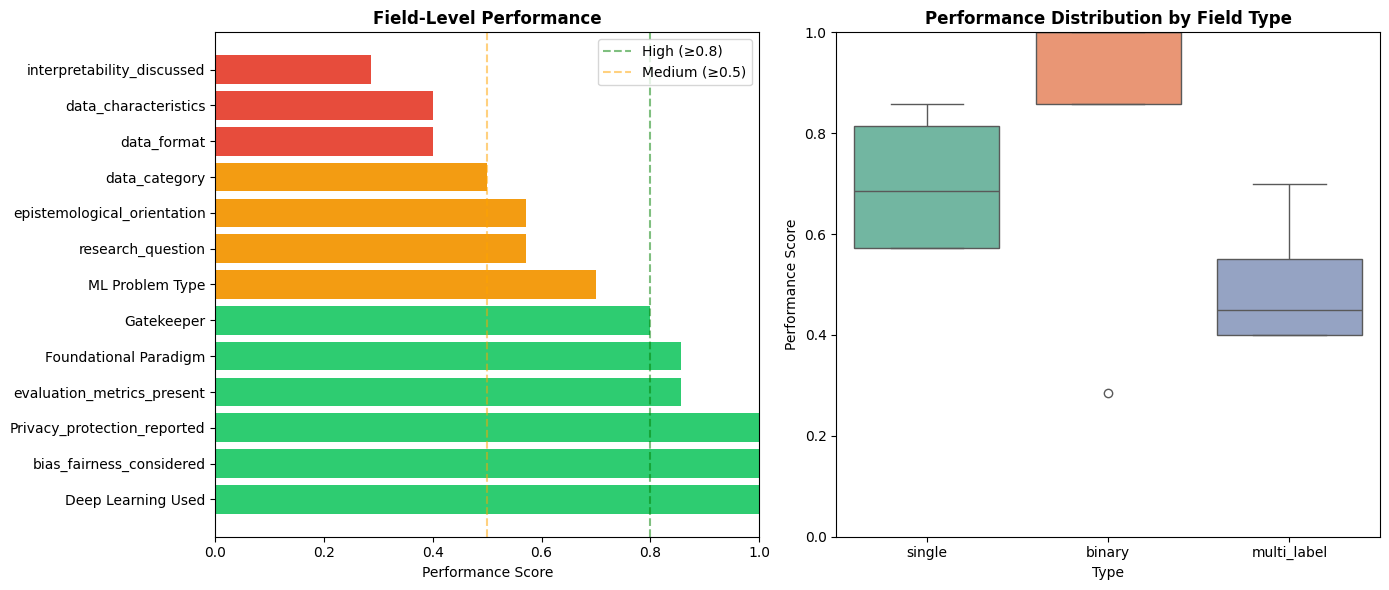

✅ Saved field_performance_analysis.png

🔍 FIELD-LEVEL PERFORMANCE BREAKDOWN

✅ High | Deep Learning Used...................... 100.00%
✅ High | bias_fairness_considered................ 100.00%
✅ High | Privacy_protection_reported............. 100.00%
✅ High | evaluation_metrics_present.............. 85.71%
✅ High | Foundational Paradigm................... 85.71%
✅ High | Gatekeeper.............................. 80.00%
⚠️  Medium | ML Problem Type......................... 70.00%
⚠️  Medium | research_question....................... 57.14%
⚠️  Medium | epistemological_orientation............. 57.14%
⚠️  Medium | data_category........................... 50.00%
❌ Low | data_format............................. 40.00%
❌ Low | data_characteristics.................... 40.00%
❌ Low | interpretability_discussed.............. 28.57%


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare visualization data
field_performance = []
for field_name, metrics in all_metrics.items():
    if metrics["field_type"] == "multi_label":
        perf_score = metrics["exact_match_ratio"]
    else:
        perf_score = metrics["accuracy"]
    
    field_performance.append({
        "Field": field_name,
        "Performance": perf_score,
        "Type": metrics["field_type"]
    })

perf_df = pd.DataFrame(field_performance).sort_values("Performance", ascending=False)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Performance by field
colors = ['#2ecc71' if p >= 0.8 else '#f39c12' if p >= 0.5 else '#e74c3c' 
          for p in perf_df["Performance"]]
ax1.barh(perf_df["Field"], perf_df["Performance"], color=colors)
ax1.set_xlabel("Performance Score")
ax1.set_title("Field-Level Performance", fontsize=12, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.axvline(x=0.8, color='green', linestyle='--', alpha=0.5, label='High (≥0.8)')
ax1.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium (≥0.5)')
ax1.legend()

# Plot 2: Performance distribution by type
type_data = []
for field_type in ["single", "binary", "multi_label"]:
    type_perfs = perf_df[perf_df["Type"] == field_type]["Performance"].tolist()
    for perf in type_perfs:
        type_data.append({"Type": field_type, "Performance": perf})

type_perf_df = pd.DataFrame(type_data)
sns.boxplot(data=type_perf_df, x="Type", y="Performance", ax=ax2, palette="Set2")
ax2.set_title("Performance Distribution by Field Type", fontsize=12, fontweight='bold')
ax2.set_ylabel("Performance Score")
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(EVALUATION_FOLDER / "field_performance_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved field_performance_analysis.png")

# Print field-level breakdown
print("\n" + "="*80)
print("🔍 FIELD-LEVEL PERFORMANCE BREAKDOWN")
print("="*80 + "\n")

for idx, row in perf_df.iterrows():
    perf_level = "✅ High" if row["Performance"] >= 0.8 else "⚠️  Medium" if row["Performance"] >= 0.5 else "❌ Low"
    print(f"{perf_level} | {row['Field']:.<40} {row['Performance']:.2%}")

In [29]:
# Error analysis
print("\n" + "="*80)
print("🔎 ERROR ANALYSIS")
print("="*80 + "\n")

# Identify papers with most mismatches
mismatch_counts = []
for _, row in multi_field_comparison.iterrows():
    mismatches = sum(1 for field in ENHANCED_BENCHMARK_MAPPING.keys() 
                    if not row.get(f"{field}_Match", False))
    match_rate = 1 - (mismatches / len(ENHANCED_BENCHMARK_MAPPING))
    mismatch_counts.append({
        "Paper ID": row["Paper ID"],
        "Mismatches": mismatches,
        "Match Rate": match_rate
    })

error_df = pd.DataFrame(mismatch_counts).sort_values("Mismatches", ascending=False)

print("📋 Papers with Most Disagreements:\n")
print(error_df.head(10).to_string(index=False))

print(f"\n\n📊 Error Statistics:")
print(f"  • Average mismatches per paper: {error_df['Mismatches'].mean():.2f}")
print(f"  • Median mismatches: {error_df['Mismatches'].median():.0f}")
print(f"  • Papers with 0 mismatches: {(error_df['Mismatches'] == 0).sum()}")
print(f"  • Average match rate: {error_df['Match Rate'].mean():.2%}")

# Per-field error frequency
print(f"\n\n❌ Fields with Highest Error Rates:\n")
field_errors = {}
for field in ENHANCED_BENCHMARK_MAPPING.keys():
    match_col = f"{field}_Match"
    if match_col in multi_field_comparison.columns:
        errors = (~multi_field_comparison[match_col]).sum()
        error_rate = errors / len(multi_field_comparison)
        field_errors[field] = error_rate

sorted_errors = sorted(field_errors.items(), key=lambda x: x[1], reverse=True)
for field, error_rate in sorted_errors[:5]:
    print(f"  {field:.<40} {error_rate:.2%} error rate")


🔎 ERROR ANALYSIS

📋 Papers with Most Disagreements:

 Paper ID  Mismatches  Match Rate
2018 - 26          12    0.076923
2018 - 12          11    0.153846
2024 - 99           5    0.615385
2021 - 56           5    0.615385
2023 - 58           5    0.615385
 2018 - 8           4    0.692308
2021 - 28           4    0.692308
 2020 - 8           4    0.692308
2019 - 33           2    0.846154
 2011 - 1           0    1.000000


📊 Error Statistics:
  • Average mismatches per paper: 5.20
  • Median mismatches: 4
  • Papers with 0 mismatches: 1
  • Average match rate: 60.00%


❌ Fields with Highest Error Rates:

  interpretability_discussed.............. 70.00% error rate
  data_format............................. 60.00% error rate
  data_characteristics.................... 60.00% error rate
  research_question....................... 50.00% error rate
  data_category........................... 50.00% error rate
